# import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")
from BasicData import *
from Flow_functions import * # import flow functions, Information to the agent
from Geometric_functions import * # Import rotation from euler angles
from Evolution_Traj import * # Import time integration for trjectories
from Time_Int_Traj import * # Import evolution function
from BasicData import *  # Nagents, R0, V
from Strategies import * # Import strategies, Braitenberg or Triangulation
from Strategies_Evolution import * # Import strategies Evolution, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 


Plot Scheme A

In [2]:
# BasicData  
# - R0 : Euclidean initial distance from target
# - NTrials : number of agents initialized

import numpy as np

Nagents = 4 # NTrials : number of agents initialized
R0 = 25 # Euclidean distance from target
V = .7 # Linear speed of the agents

# Determine domain of motion of the agent
RMIN = 1 # Minimal distance with respect to prey
TMAX = 20*np.pi*(R0) # Maximum time allowed for the simulation
dt = 0.1 # Time steps for time integration
e3 = np.array([0,0,1]) # Orientation of symmetry axis of source flow
AntennaeLength = .1  # Distance between sensors
BodyWidth = .1 # Not used

# Define information flow 
Grads = [GradientStresslet] # StrainStresslet, GradientStresslet, StrainStokeslet, GradientStokeslet 
GradName = 'GradientStresslet' # 'StrainStresslet', 'GradientStresslet', 'StrainStokeslet', 'GradientStokeslet'

#Twist setting
twists = [0.0, 0.3] # Imposed twist

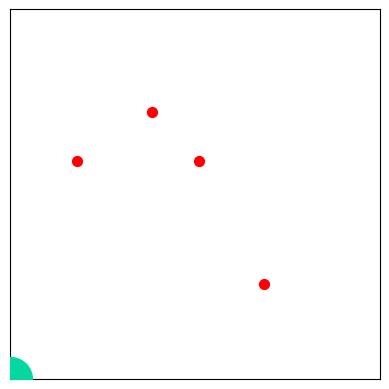

In [3]:
# Plot scheme A, plot the scheme A in Fig.3 

fig = plt.figure()
ax = fig.add_subplot(111)

# Set agent positions
Thetas = np.array([np.pi/4, np.pi/4, np.pi/2.5, np.pi/6])
phi = np.array([np.pi/2.5, np.pi/6, np.pi/6, np.pi/8])
AgentPositions = R0*np.array([np.sin(Thetas)*np.cos(phi), np.sin(Thetas)*np.sin(phi), np.cos(Thetas)]).T.reshape((Nagents,3))

# Plots
ax.scatter(0.0, 0.0, s=1000, marker='o', color = '#06d6a0', zorder = 3)
ax.scatter(AgentPositions[:,0], AgentPositions[:,2], s=50 ,marker='o', c='red')


ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim([0, R0 + 5])
ax.set_ylim([0, R0 + 5])
ax.set_aspect('equal',adjustable='box')

# Uncomment to save
# plt.savefig("Scheme_A_Fig3.png", bbox_inches = 'tight')

plt.show()

Plot Trajectories

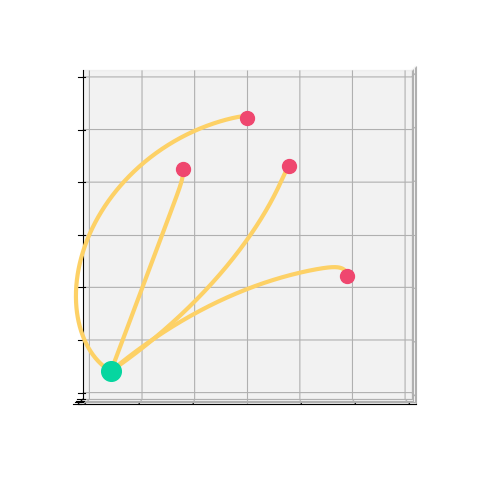

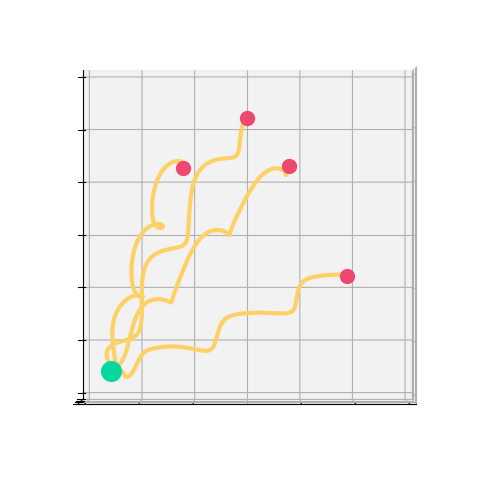

In [65]:
# Code to Evolve and plot the trajectories in 3D
# It calculates evolution for both strategies: Braitenberg and Triangulation
#


from matplotlib.patches import Circle
import mpl_toolkits.mplot3d.art3d as art3d
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Realize Evolution
Strategies = [Evolution_Triangulation]  # Evolution_Braitenberg ,Evolution_Triangulation
StrategyName = "T" # "B", "T"
twist_on = ["off", "on"]
for strat_i, Strategy in enumerate(Strategies):
	for grad_i, Grad in enumerate(Grads):
		for twist_i, twist in enumerate(twists):
			Trajectories_x, Trajectories_y, Trajectories_z, Successes = Evolution(Grad, Strategy, twist, AgentPositions)

			fig = plt.figure(figsize=(6, 6))
			ax = fig.add_subplot(111, projection='3d')

			

			for a in range(Nagents):
				ax.plot(Trajectories_x[a], Trajectories_y[a], Trajectories_z[a], color='#fdd166', alpha=1, linewidth= 3)	
				ax.scatter(Trajectories_x[a][0], Trajectories_y[a][0], Trajectories_z[a][0], color='#ef476f', s= 100)	
			ax.scatter(0,0,0, s=200, marker='o', color = '#06d6a0')#, label='Target')
			ax.set_xlim([-2, R0])
			ax.set_ylim([-2, 2])
			ax.set_zlim([0., R0])
			xticks = np.linspace(-2, R0, 7)
			yticks = np.linspace(-2, 2, 4)
			zticks = np.linspace(-2, R0, 7)

			empty_labels_x = ["" for i in range(7)]
			empty_labels_y = ["" for i in range(4)]
			empty_labels_z = ["" for i in range(7)]

			ax.set_xticks(xticks, empty_labels_x)
			ax.set_yticks(yticks, empty_labels_y)
			ax.set_zticks(zticks, empty_labels_z)
		

			ax.set_box_aspect(aspect = (1, .2, 1))
			ax.view_init(0, 270)
			# ax.set_title(StrategyName[strat_i])
			
            # Uncomment to save
			plt.savefig("Plots/"+GradName+"_"+StrategyName+"_"+twist_on[twist_i]+".png",bbox_inches='tight')
			plt.show()


# Plot trajectories 3D

In [69]:
# Code to Evolve and plot the trajectories in 3D
# It calculates evolution for both strategies: Braitenberg and Triangulation
#

from matplotlib.patches import Circle
import mpl_toolkits.mplot3d.art3d as art3d
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Realize Evolution
Strategies = [Evolution_Triangulation]  # Evolution_Braitenberg, Evolution_Triangulation
StrategyName = "T"  # "B", "T"
twist_on = ["off", "on"]
for strat_i, Strategy in enumerate(Strategies):
    for grad_i, Grad in enumerate(Grads):
        for twist_i, twist in enumerate(twists):
            Trajectories_x, Trajectories_y, Trajectories_z, Successes = Evolution(Grad, Strategy, twist, AgentPositions)

            


-0.16822307582114213


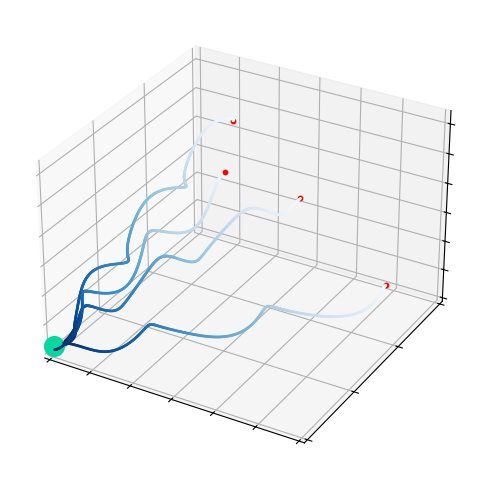

In [70]:

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

for a in range(Nagents):
    ax.scatter(Trajectories_x[a], Trajectories_y[a], Trajectories_z[a], c=plt.cm.Blues(np.linspace(0,1,len(Trajectories_x[a]))), alpha=1, s=1)
    ax.scatter(Trajectories_x[a][0], Trajectories_y[a][0], Trajectories_z[a][0], color='red', s=10)

ax.scatter(0, 0, 0, s=200, marker='o', color='#06d6a0')  # Target marker
print(min(min(Trajectories_z)))
ax.set_xlim([min(min(Trajectories_x)), max(max(Trajectories_x))])
ax.set_ylim([min(min(Trajectories_y)), max(max(Trajectories_y))])
ax.set_zlim([min(min(Trajectories_z)), max(max(Trajectories_z))])

xticks = np.linspace(min(min(Trajectories_x)), max(max(Trajectories_x)), 7)
yticks = np.linspace(min(min(Trajectories_y)), max(max(Trajectories_x)), 4)
zticks = np.linspace(min(min(Trajectories_z)), max(max(Trajectories_x)), 7)

empty_labels_x = ["" for _ in range(7)]
empty_labels_y = ["" for _ in range(4)]
empty_labels_z = ["" for _ in range(7)]

ax.set_xticks(xticks)
ax.set_xticklabels(empty_labels_x)
ax.set_yticks(yticks)
ax.set_yticklabels(empty_labels_y)
ax.set_zticks(zticks)
ax.set_zticklabels(empty_labels_z)

# Uncomment to save
plt.savefig("Plots/"+GradName+"_"+StrategyName+"_"+twist_on[twist_i]+".png", bbox_inches='tight')
plt.show()

In [73]:
import pandas as pd
for a in range(Nagents):
    ToSave = pd.DataFrame({'tj_x': Trajectories_x[a], 'tj_y' : Trajectories_y[a], 'ty_z': Trajectories_z[a]})
    ToSave.to_csv(f'Trajectories_agent_{a}.csv', index=False)